In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path
import shutil
sys.path.insert(0, '/home/mwalker/git/neoexchange/neoexchange') #point to top of file path
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'neox.settings')
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')

import django
django.setup()
from django.conf import settings

import pandas as pd
import numpy as np
from IPython.display import display

from core.models import Body #Body Class
from core.models.sources import StaticSource #static class
from core.models.blocks import Block  #Block class
from core.models.frame import Frame 


os.chdir("/home/mwalker/git/neoexchange/neoexchange") #temp fix for json issue
from core.views import summarize_block_quality
#from core.views import GuideMovie
#from core.plots import generalized_fwhm_plotter, generalized_zeropoint_plotter  #get pngs for fwhm and zp to analyze
from astrometrics.ephem_subs import horizons_ephem
from core.models import Block, StaticSource


from datetime import datetime
from astropy.coordinates import SkyCoord, Angle
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.time import Time
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
from astropy.table import Table


from photutils import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats  #investigate documentatiom for this
from astropy.stats import sigma_clipped_stats


/tmp/ipykernel_24817/2411458046.py:53: DeprecationWarning: `photutils.DAOStarFinder` is a deprecated alias for `photutils.detection.DAOStarFinder` and will be removed in the future. Instead, please use `from photutils.detection import DAOStarFinder` to silence this warning.
  from photutils import DAOStarFinder


In [8]:
fields = StaticSource.objects.filter(source_type = StaticSource.REFERENCE_FIELD, name__contains = '2026')


input_dir = Path("/apophis/eng/rocks/Hera/20260719")
output_root =Path("/home/mwalker/git/Didymos_data")
output_root.mkdir(parents = True, exist_ok = True)

# Copy each file into the directory f2 as Didiymos is in that field rn...
fits_names = [f for f in input_dir.glob(f"*ep09*-*e93.fits*")
               if ".fz" not in f.name]  #selects fits

field_num_ = []
obs_info = []
for field in fields:

    # Extract the field number from the name
    field_num = field.name.split("#")[-1].strip()
    field_num_.append(field_num)
    # Create output directory (f1, f2, ..., f16)
    outdir = output_root / f"f{field_num}_019_e93"
    outdir.mkdir(parents=True, exist_ok=True)
    
    ra = field.ra
    dec = field.dec


    for file in fits_names:
        ep = file.name.split("-")[1].strip(" ")
        # Only ep07 files
        if ep != "ep09":
            continue

        with fits.open(file) as hdul:
            wcs = WCS(hdul[0].header)
            data = hdul[0].data
            header = hdul[0].header
            date_obs = header["DATE-OBS"]

            x,y = wcs.world_to_pixel_values(ra,dec)    #Check if x,y of fits in field #2

            ny , nx = data.shape

            if 0 <= x <= nx and 0 <=y <= ny:
                print(f"{file.name} found in and copying to {field.name}_019_e93")      
                shutil.copy2(file, outdir/ file.name)
                print(f"{file.name} time of obs is {date_obs}")
                obs_info.append({
                        "field": field.name,
                        "time": Time(date_obs, format="isot", scale="utc"),
                        "file": file.name,
                    })
                        


    # for ref_file in ref_filepaths:
    #     shutil.copy2(ref_file, outdir / ref_file.name)


In [18]:

# Fetch all reference field
coj_fields = StaticSource.objects.filter(source_type=StaticSource.REFERENCE_FIELD, name='Didymos COJ 2026 Field #06').order_by('name')  #get ra/dec 

# Get the ephemeris for Didymos; returns an Astropy Table
ephem_FTS = horizons_ephem('65803', datetime(2026,7,12), datetime(2026,7,13), 'E10', '5m', alt_limit=30)
nighttime_mask = ephem_FTS['solar_presence'] == ''
ephem_FTS = ephem_FTS[nighttime_mask]

# For the start and the end of the ephemeris (first and last row of `ephem_FTS`) compute the separation between Didymos's position (given by `RA` and `DEC` columns) at that time with that of each of the Fields in `coj_fields`.
# Hint: make SkyCoord's out of Didymos's position and the reference field and then look at spherical_offsets_to()

selected_rows = []

for file in fits_names:

    # Only use ep07 files
    if file.name.split("-")[1] != "ep07":
        continue

    with fits.open(file) as hdul:
        date_obs = Time(hdul[0].header["DATE-OBS"], format="isot", scale="utc")

    # Find closest ephemeris time
    idx = np.argmin(np.abs(ephem_FTS["datetime"] - date_obs))
    selected_rows.append(ephem_FTS[idx])

selected_rows = Table(rows=selected_rows, names=ephem_FTS.colnames)

ra_ = selected_rows["RA"]

ra_ds9 = []
for ra in ra_:
    ra = Angle(ra * u.deg)
    string = ra.to_string(unit = u.hour, sep = ":", precision = 4)
    ra_ds9.append(string)
    
#selected_rows["RA"] = ra_ds9
display(selected_rows)
print(np.min(ephem_FTS["RA"]), np.max(ephem_FTS["RA"]))
print(np.min(ephem_FTS["DEC"]), np.max(ephem_FTS["DEC"]))

targetname,datetime_str,datetime_jd,H,G,solar_presence,lunar_presence,RA,DEC,RA_rate,DEC_rate,AZ,EL,V,surfbright,r,r_rate,delta,delta_rate,elong,elongFlag,alpha,RSS_3sigma,hour_angle,GlxLon,GlxLat,Sky_motion,Sky_mot_PA,RelVel-ANG,datetime,mean_rate
str23,str17,float64,float64,float64,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,float64,float64,float64,float64,float64,float64,float64,Time,float64
65803 Didymos (1996 GT),2026-Jul-12 09:00,2461233.875,18.11,0.15,,,240.25906,-22.23672,-0.5066016666666666,0.013799433333333333,75.505917,64.943107,20.412,5.374,1.802899070867,-7.8450513,0.94949946563455,6.1253623,132.9638,/T,24.3661,0.001,-1.753988739,350.51864,22.643792,0.5067899,271.56031,46.479095,2026-07-12 09:00:00,0.5067895747050896
65803 Didymos (1996 GT),2026-Jul-12 09:00,2461233.875,18.11,0.15,,,240.25906,-22.23672,-0.5066016666666666,0.013799433333333333,75.505917,64.943107,20.412,5.374,1.802899070867,-7.8450513,0.94949946563455,6.1253623,132.9638,/T,24.3661,0.001,-1.753988739,350.51864,22.643792,0.5067899,271.56031,46.479095,2026-07-12 09:00:00,0.5067895747050896
65803 Didymos (1996 GT),2026-Jul-12 09:20,2461233.888888889,18.11,0.15,,,240.25602,-22.23664,-0.5074166666666666,0.014800116666666667,69.896421,69.03817,20.412,5.374,1.802836141089,-7.8455385,0.94954873231825,6.1578565,132.9478,/T,24.3738,0.001,-1.419539941,350.516556,22.645849,0.5076326,271.67071,46.581445,2026-07-12 09:20:00,0.5076324625794316
65803 Didymos (1996 GT),2026-Jul-12 09:05,2461233.878472222,18.11,0.15,,,240.2583,-22.2367,-0.5068283333333333,0.01404575,74.24211,65.977928,20.412,5.374,1.802883338789,-7.8451731,0.94951175793667,6.1333774,132.9598,/T,24.368,0.001,-1.670376574,350.518119,22.644305,0.507023,271.58743,46.502979,2026-07-12 09:05:00,0.5070229211411521
65803 Didymos (1996 GT),2026-Jul-12 09:15,2461233.885416667,18.11,0.15,,,240.25678,-22.23666,-0.5072366666666667,0.014546216666666667,71.449719,68.026603,20.412,5.374,1.802851873899,-7.8454167,0.94953639113594,6.149628,132.9518,/T,24.3719,0.001,-1.503152174,350.517077,22.645334,0.5074445,271.64264,46.554165,2026-07-12 09:15:00,0.50744519746513
65803 Didymos (1996 GT),2026-Jul-12 09:15,2461233.885416667,18.11,0.15,,,240.25678,-22.23666,-0.5072366666666667,0.014546216666666667,71.449719,68.026603,20.412,5.374,1.802851873899,-7.8454167,0.94953639113594,6.149628,132.9518,/T,24.3719,0.001,-1.503152174,350.517077,22.645334,0.5074445,271.64264,46.554165,2026-07-12 09:15:00,0.50744519746513
65803 Didymos (1996 GT),2026-Jul-12 09:10,2461233.881944444,18.11,0.15,,,240.25754,-22.23668,-0.5070399999999999,0.014294716666666665,72.893843,67.006109,20.412,5.374,1.802867606466,-7.8452949,0.94952406638843,6.1414672,132.9558,/T,24.37,0.001,-1.586764385,350.517598,22.64482,0.5072413,271.61488,46.528006,2026-07-12 09:10:00,0.5072414617562135
65803 Didymos (1996 GT),2026-Jul-12 09:40,2461233.902777778,18.11,0.15,,,240.25297,-22.23655,-0.5079833333333333,0.01583725,62.235377,72.961038,20.413,5.374,1.802773207409,-7.8460258,0.94959826392454,6.1913735,132.9317,/T,24.3816,0.001,-1.085090828,350.514473,22.647914,0.5082305,271.78571,46.701543,2026-07-12 09:40:00,0.5082301500619645
65803 Didymos (1996 GT),2026-Jul-12 09:30,2461233.895833333,18.11,0.15,,,240.25449,-22.23659,-0.5077316666666667,0.015314649999999999,66.397161,71.02836,20.412,5.374,1.802804674737,-7.8457821,0.94957346450758,6.1745016,132.9397,/T,24.3777,0.001,-1.252315418,350.515514,22.646881,0.5079626,271.72768,46.639322,2026-07-12 09:30:00,0.5079625811422862


240.20346 240.26134
-22.23679 -22.23422


In [19]:
matched = []

for file in fits_names:

    if file.name.split("-")[1] != "ep07":
        continue

    with fits.open(file) as hdul:
        date_obs = Time(hdul[0].header["DATE-OBS"], format="isot", scale="utc")

    idx = np.argmin(np.abs(ephem_FTS["datetime"] - date_obs))

    matched.append({
        "file": file,
        "time": date_obs,
        "ephem": ephem_FTS[idx]
    })

    for item in matched:
        file = item["file"]
        row = item["ephem"]

        ra = row["RA"]
        dec = row["DEC"]

In [20]:
#fucntion of circular aperature + sum and - bk

def circular_aperture_photometry(center_x, center_y, radius,file_path):
    """
    Perform (very ROUGH!!!) Circular aperature photometry on image data

    Inputs:
    - image_data: 2D numpy array representing the image
    - center_x: x-coordinate of the center of the aperature (pixels)
    - center_y: y-coordinate of the center of the aperature (pixels)
    - radius: radius of the aperature (pixels)
    
    Returns:
    - aperature_sum: sum of pixel values within the aperature minus background
    - SNR: signal-to-noise ratio of the aperature photometry
    """

    with fits.open(file_path) as hdul:
        header = hdul[0].header
        image_data = hdul[0].data
        zp = header.get('ZP', 25.0)  # Default zero point if not found in header
        
    background = np.median(image_data)
    y, x = np.indices(image_data.shape)
    aperature_mask = (x-center_x)**2 + (y-center_y)**2 <= radius**2

    aperature_sum = np.sum(image_data[aperature_mask]) - background*np.sum(aperature_mask)        #bk * num_pixels = total flux
    SNR = aperature_sum / np.sqrt(aperature_sum + np.sum(aperature_mask) * background)  #SNR = signal / sqrt(signal + noise)
    appar_mag = -2.5 * np.log10(aperature_sum) + zp  #apparent magnitude = -2.5 * log10(flux)
    return aperature_sum, SNR, appar_mag



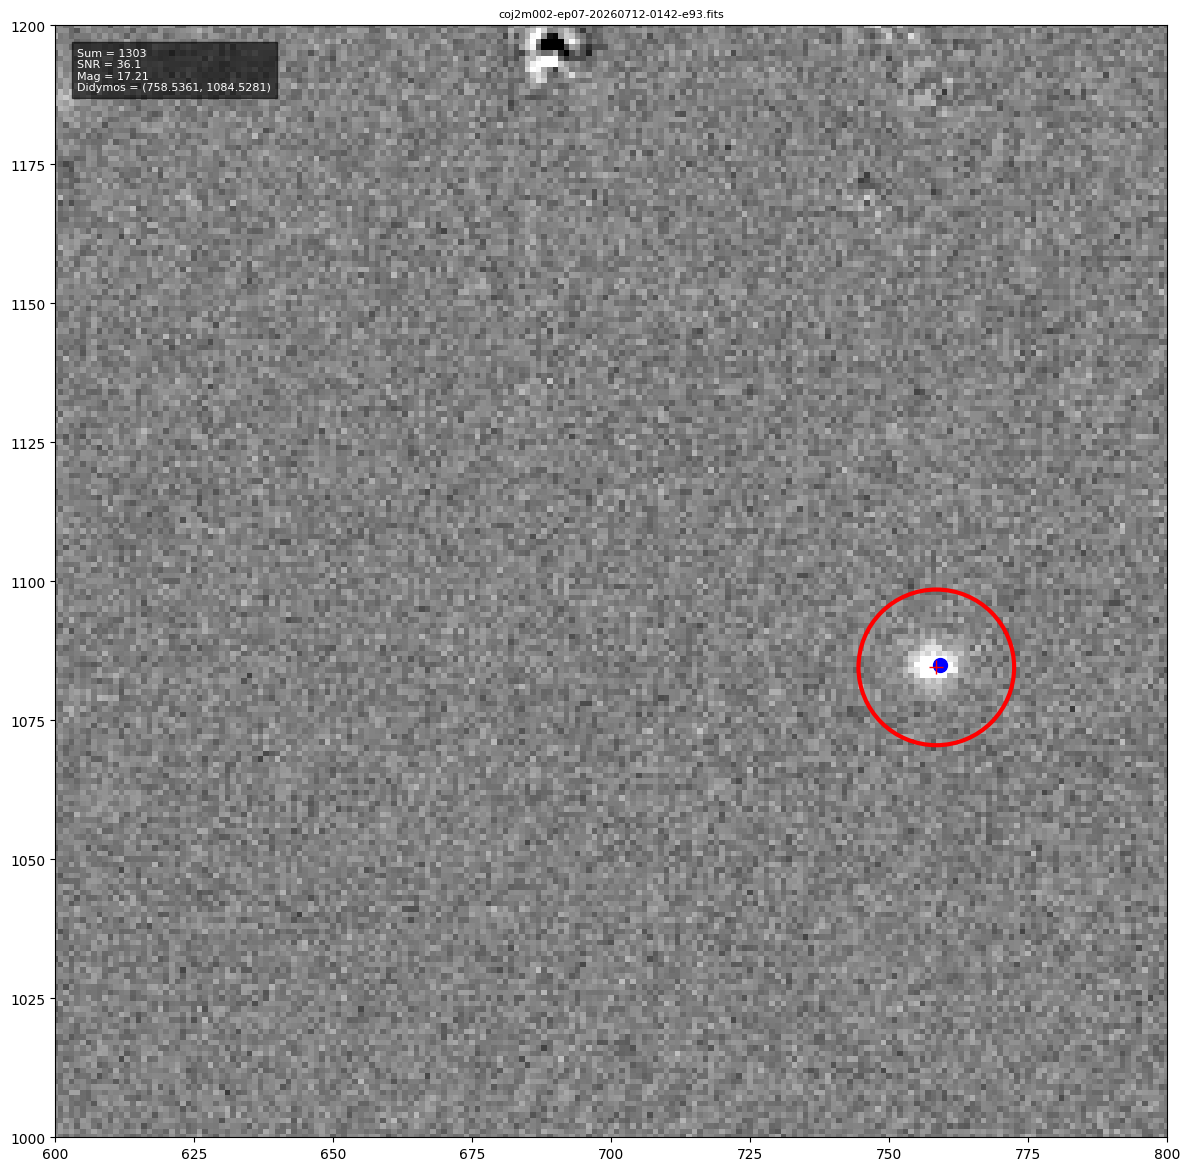

In [38]:
### plot the aperature centered on the ra and dec in each of the frames of the e07 ###

#fig, axes =  plt.subplots(3, 3, figsize=(12, 14))
fig, axes = plt.subplots(1,1, figsize = (12,14))
#axes = axes.ravel()  #2D -> 1D array 

ra__2 = selected_rows["RA"]
dec__2 = selected_rows["DEC"]
time__2 = selected_rows["datetime"]
ra = ra__2[0]
dec = dec__2[0]

f2_path = Path("/home/mwalker/git/Didymos_data/f06_012_e93/")

f_2_files = sorted(f2_path.glob(f"*coj2m002-ep07-20260712-0058-e93.fits*"))
files = f_2_files[0]

didymos_stats_2 = []
pix_c_d = np.zeros((len(ra__2),2))

with fits.open(files) as hdul:

    header = hdul[0].header
    data= hdul[0].data

    # Extract the WCS information from the header
    wcs_info = WCS(header)
    coord = SkyCoord(ra = ra*u.deg, dec = dec*u.deg)
    x, y = wcs_info.world_to_pixel(coord)
    pix_c_d = x,y  #append positions for photutils
    file_p = file

    aperture_sum, SNR, appar_mag = circular_aperture_photometry(x , y, 13,file_p )

    didymos_stats_2.append({
        "apperature_Sum": aperture_sum,
        "SNR": SNR, 
        "Apaprent Magnitude": appar_mag
    })


#plotting
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data)
axes.imshow(data, origin = "lower", cmap ="gray", vmin=vmin, vmax=vmax)
axes.plot(x,y, "r+", markersize = 10)
circle = Circle((x,y), 14, fill= False, color = "red", linewidth = 3)
axes.add_patch(circle)
axes.set_title(file.name, fontsize = 8)
axes.set_xlim(600,800)
axes.set_ylim(1000,1200)
axes.scatter(759.13,1084.892, color = "blue", s = 100)  #ds9 point
axes.text(
0.02, 0.98,
f"Sum = {aperture_sum:.0f}\n"
f"SNR = {SNR:.1f}\n"
f"Mag = {appar_mag:.2f}\n"
f"Didymos = ({x:.4f}, {y:.4f})",
transform=axes.transAxes,
fontsize=8,
color="white",
verticalalignment="top",
bbox=dict(facecolor="black", alpha=0.6)
)
# #graph the image of the (reference frame 13 with the bright star marked on it


plt.tight_layout()


save_dir_ds9= "/home/mwalker/git/Didymos_data/f02/"
plt.savefig (os.path.join(save_dir_ds9 , "didymos_ds9.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()
plt.show()


#NOTE:   Didymos disappears into PSF of the other star





In [29]:
print("WCS:",x,y)
print("DS9:",759.13,1084.892)

print(
    np.sqrt(
        (x-759.13)**2 +
        (y-1084.892)**2
    )
)

WCS: 1319.5780362860464 1108.0835040634072
DS9: 759.13 1084.892
560.9276666715671
